In [ ]:
import torch
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import torchvision

import matplotlib.pyplot as plt
import numpy as np
# Stupid

device = "cuda" if torch.cuda.is_available() else "cpu"

# -----------------------
# 1. Load pretrained model
# -----------------------
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

import torch.optim as optim

!gdown --id 1NW2A_4yJi-ruAFkcM2ZwVu0paAxWoP1L

PATH = './cifar_net.pth'

net = Net()
net.load_state_dict(torch.load(PATH, map_location=torch.device(device)))

net.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)


/home/cv04f26/.conda/envs/tankenv/lib/python3.14/site-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1NW2A_4yJi-ruAFkcM2ZwVu0paAxWoP1L
To: /home/cv04f26/ComputerVisionProject/Mathijs/cifar_net.pth
100%|████████████████████████████████████████| 251k/251k [00:00<00:00, 2.28MB/s]


In [14]:
import os

# Prefer writing into /mnt/scratch if it exists (common on shared GPU nodes)
# Otherwise fall back to the current working directory.
PWD = os.getcwd()
SCRATCH = "/mnt/scratch"

if os.path.isdir(SCRATCH):
    data_root = os.path.join(SCRATCH, "data")
else:
    data_root = os.path.join(PWD, "data")

os.makedirs(data_root, exist_ok=True)
print("Using data root:", data_root)

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 1

trainset = torchvision.datasets.CIFAR10(root=data_root, train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root=data_root, train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print("Train size:", len(trainset))
print("Test size:", len(testset))


Using data root: /mnt/scratch/data


/home/cv04f26/.conda/envs/tankenv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train size: 50000
Test size: 10000


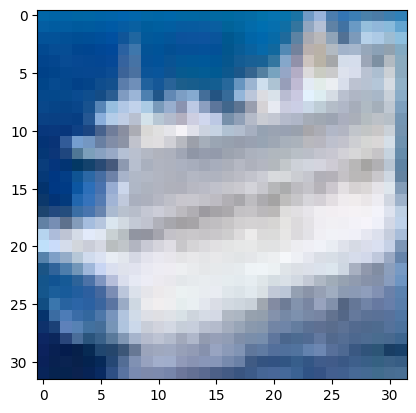

ship 


In [15]:
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [9]:
net

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

### NOTES

- You want to use GradCAM usually on the last convolutional layer, as this has the highest semantic information, but remains spatial information. This needs interpolation techniques to upsample to the original input dimension, however. 
- It is important to note that GradCAM focuses on pixels and its gradient WITH RESPECT TO a certain logit class. So choosing a different logit, yields different derivates -> hence activations are different in the feature maps -> different heatmap.

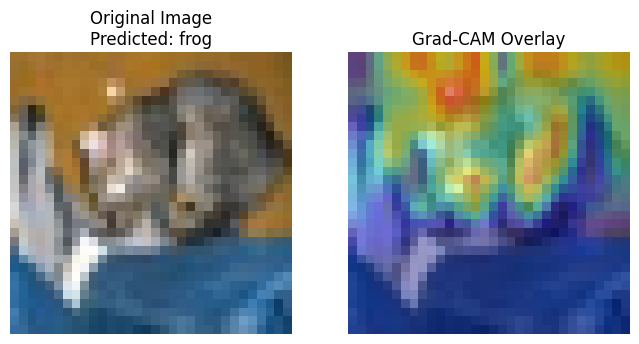

torch.Size([1, 16, 10, 10])

In [18]:
import torch
import torch.nn.functional as F

# -----------------------
# 1. Choose your target layer
# -----------------------
# For Grad-CAM, pick the last convolution layer
target_layer = net.conv2  # <-- your choice

# -----------------------
# 2. Storage for hooks
# -----------------------
activations = None
gradients = None

# define hooks
def forward_hook(module, input, output):
    global activations
    activations = output

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

# -----------------------
# 3. Register hooks
# -----------------------
# forward hook: store activations
target_layer.register_forward_hook(forward_hook)

# backward hook: store gradients
target_layer.register_full_backward_hook(backward_hook)

# -----------------------
# 4. Prepare input
# -----------------------
# For example, pick one CIFAR10 image:
images, labels = next(iter(testloader))
images, labels = images.to(device), labels.to(device)

# -----------------------
# 5. Forward pass
# -----------------------
outputs = net(images)
pred_class = outputs.argmax(dim=1)

# print(pred_class)

# Choose a single sample (here: the first in the batch) for Grad-CAM
target_class = pred_class[0].item()

# -----------------------
# 6. Backward pass
# -----------------------
# Zero gradients
net.zero_grad()

# Compute gradient of the target class score for the first sample
score = outputs[0, target_class]
score.backward()

# At this point:
# activations: feature maps of conv2
# gradients: gradients of score w.r.t. conv2

# -----------------------
# 7. Grad-CAM computation
# -----------------------
# TODO (your implementation):
# gradients, activations (B, C, H, W)

# 1. Global average pool gradients over H,W -> weights
weights = gradients.mean(dim=(2,3), keepdim=True)  # (B, C, 1, 1)

# 2. Weighted sum of activations using these weights
cam = (weights * activations).sum(dim=1)            # (B, H, W)

# 3. Apply ReLU
cam = torch.relu(cam)

# 4. Normalize to the range [0, 1]
with torch.no_grad():
    B, H, W = cam.shape
    cam = cam.view(B, -1)  # (B, H*W)
    cam_min = cam.min(dim=1, keepdim=True).values
    cam_max = cam.max(dim=1, keepdim=True).values
    cam = (cam - cam_min) / (cam_max - cam_min + 1e-6)
    cam = cam.view(B, H, W)  # Restore size
    
# 5. Upsample to image size (32x32)
cam = cam.unsqueeze(1)  # Add the channel dimension back
cam = F.interpolate(cam, size=(32, 32), mode="bilinear", align_corners=False)

# 6. Overlay heatmap on original image
# Squeeze to (32, 32) for the heatmap
heatmap = cam.squeeze(0).squeeze(0).cpu().numpy()

# Unnormalize the original image for display
original_image = images[0].cpu()  # (3, 32, 32)
original_image = original_image * 0.5 + 0.5  # Unnormalize
original_image = original_image.permute(1, 2, 0).numpy()  # (32, 32, 3)

# Apply colormap to heatmap using matplotlib
import matplotlib.cm as cm
heatmap_colored = cm.jet(heatmap)[:, :, :3]  # (32, 32, 3), RGBA to RGB

# Blend with original image (alpha=0.4 for heatmap transparency)
overlay = 0.6 * original_image + 0.4 * heatmap_colored

# Display
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(original_image)
plt.title(f"Original Image\nPredicted: {classes[pred_class[0].item()]}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(overlay)
plt.title("Grad-CAM Overlay")
plt.axis('off')

plt.show()

# activations

gradients.shape